# Loan Eligibility Prediction
Professional Data Science Project

Author: Kabelo Motshabi Makgae

## 1. Import Libraries

In [59]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. Load Dataset

In [60]:
df = pd.read_csv('../data/train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Dataset Shape

Before building any machine learning model, it is important to understand the size of the dataset. The shape tells us how many observations (rows) and features (columns) are available for analysis.

In [61]:
df.shape

(614, 13)

### Interpretation

The dataset contains **614 loan applications** and **13 features** describing each applicant.

These features will be analyzed to determine whether they influence loan approval.

## Dataset Information

This section provides an overview of each feature, including its data type and whether any missing values are present.

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


### Interpretation

The dataset contains both numerical and categorical variables.

Some variables contain missing values, which will need to be handled before building machine learning models.

## Statistical Summary

The statistical summary provides descriptive statistics for numerical features such as mean, minimum, maximum, and standard deviation.

In [63]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


### Interpretation

The descriptive statistics help us understand the distribution of numerical variables and identify potential outliers or unusual values.

## Missing Values

Machine learning algorithms cannot work effectively with missing values.

Therefore, it is necessary to identify which features contain missing observations before performing data cleaning.

In [64]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### Interpretation

Several columns contain missing values.

These missing values will be replaced using appropriate techniques such as the median for numerical variables and the mode for categorical variables.

## Duplicate Records

Duplicate records can introduce bias into the model and should be identified before proceeding with the analysis.

In [65]:
df.duplicated().sum()

np.int64(0)

### Interpretation

No duplicate records were found in the dataset.

# Data Cleaning

Real-world datasets are rarely clean. Before training a machine learning model, it is important to identify and handle missing values, remove unnecessary features, and prepare the data for analysis.

In this section, the dataset will be cleaned to improve the quality of the data and ensure that the machine learning models produce reliable results.

In [66]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599
Education,0,0.000000
Loan_ID,0,0.000000
CoapplicantIncome,0,0.000000


### Interpretation

The table above shows the number and percentage of missing values in each feature.

Several variables contain missing observations, including:

- LoanAmount
- Loan_Amount_Term
- Credit_History
- Self_Employed
- Dependents
- Married
- Gender

These missing values must be handled before building machine learning models because many algorithms cannot process incomplete data.

## Handling Missing Values

Categorical variables will be filled using the **mode**, as it represents the most frequently occurring category.

Numerical variables will be filled using the **median**, which is less sensitive to outliers than the mean.

In [67]:
# Fill categorical columns

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Married"] = df["Married"].fillna(df["Married"].mode()[0])

df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

# Fill numerical columns

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [68]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### Interpretation

After handling the missing values, all columns contain zero missing observations.

The dataset is now complete and ready for further analysis and machine learning.

## Duplicate Records

Duplicate records may introduce bias into machine learning models. Therefore, it is important to verify whether duplicate observations exist within the dataset.

In [69]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


### Interpretation

The dataset contains no duplicate records.

Therefore, no duplicate rows need to be removed before model development.

## Removing Unnecessary Features

The **Loan_ID** column is a unique identifier assigned to each loan application.

Since it does not contribute to predicting whether a loan will be approved, it will be removed from the dataset.

In [70]:
df.drop("Loan_ID", axis=1, inplace=True)

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Interpretation

The Loan_ID column has been successfully removed.

The remaining variables will be used to build the machine learning models.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of exploring and visualizing data to discover patterns, relationships, and trends.

The goal of this section is to better understand the factors that influence loan approval and identify important variables before building machine learning models.

## Loan Approval Distribution

This visualization shows the distribution of approved and rejected loan applications within the dataset.

Understanding the target variable helps determine whether the dataset is balanced or imbalanced.

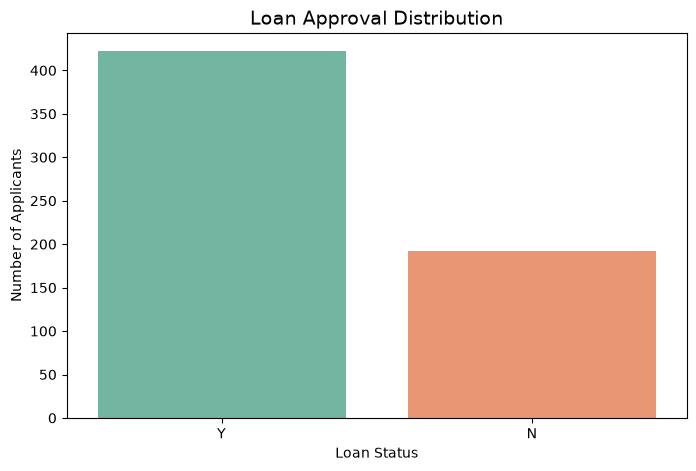

In [71]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Loan_Status",
    palette="Set2"
)

plt.title("Loan Approval Distribution", fontsize=14)

plt.xlabel("Loan Status")

plt.ylabel("Number of Applicants")

plt.show()

## Loan Approval by Gender

This chart examines whether gender has an influence on loan approval.

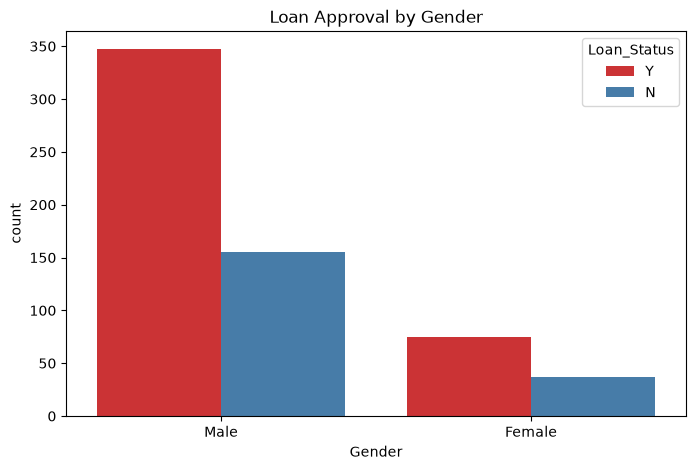

In [72]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Loan_Status",
    palette="Set1"
)

plt.title("Loan Approval by Gender")

plt.show()

### Interpretation

The visualization compares loan approval outcomes between male and female applicants.

Although male applicants appear more frequently in the dataset, both genders show a similar approval pattern.

This suggests that gender alone may not be a strong predictor of loan approval.

## Loan Approval by Education Level

This chart investigates whether education level influences loan approval.

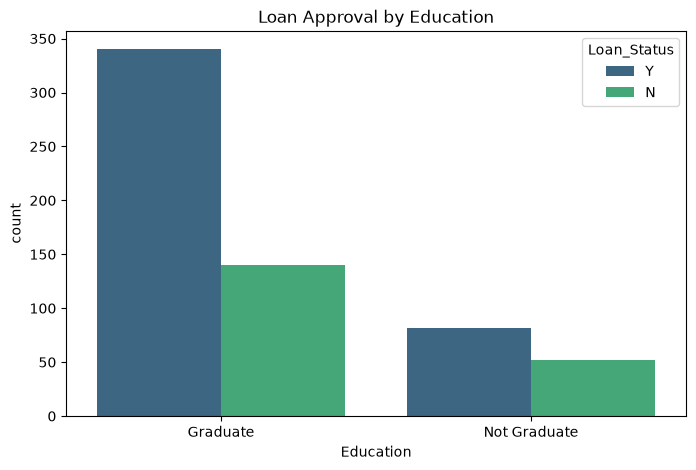

In [73]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Education",
    hue="Loan_Status",
    palette="viridis"
)

plt.title("Loan Approval by Education")

plt.show()

### Interpretation

Applicants with graduate-level education appear to receive more loan approvals than non-graduates.

However, this may also reflect the larger number of graduate applicants in the dataset.

Further analysis would be required to determine the true relationship.

## Loan Approval by Credit History

Credit history is expected to be one of the strongest predictors of loan approval.

This visualization examines how previous credit behavior affects loan approval decisions.

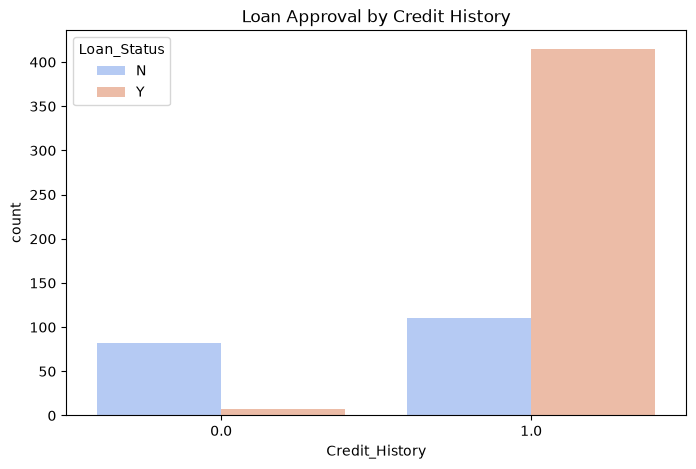

In [74]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status",
    palette="coolwarm"
)

plt.title("Loan Approval by Credit History")

plt.show()

### Interpretation

Applicants with a positive credit history are significantly more likely to receive loan approval.

This indicates that credit history is one of the strongest features influencing loan approval and is expected to contribute substantially to the predictive performance of the machine learning models.

## Applicant Income Distribution

The distribution of applicant income helps identify income ranges and detect potential outliers.


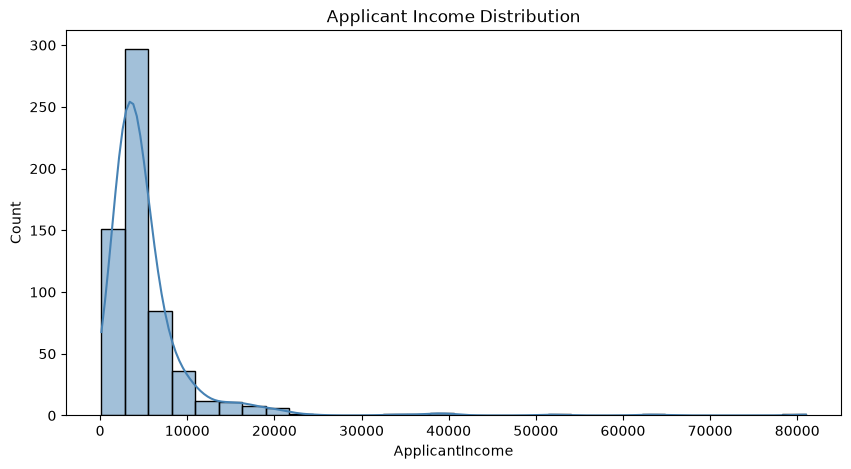

In [75]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["ApplicantIncome"],
    kde=True,
    bins=30,
    color="steelblue"
)

plt.title("Applicant Income Distribution")

plt.show()

### Interpretation

The distribution is positively skewed, indicating that most applicants earn moderate incomes while a small number earn significantly higher incomes.

These high-income applicants appear as outliers.

## Loan Amount Distribution

This visualization examines the distribution of loan amounts requested by applicants.

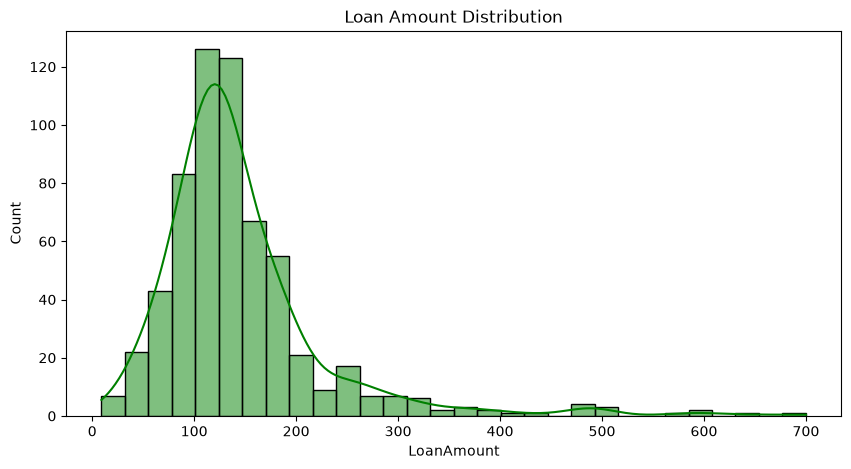

In [76]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["LoanAmount"],
    kde=True,
    bins=30,
    color="green"
)

plt.title("Loan Amount Distribution")

plt.show()

### Interpretation

Most applicants requested moderate loan amounts, while relatively few requested very large loans.

The distribution exhibits a positive skew similar to applicant income.

## Correlation Heatmap

The correlation heatmap illustrates the relationships between numerical variables.

It helps identify variables that may influence loan approval and reveals relationships among predictor variables.

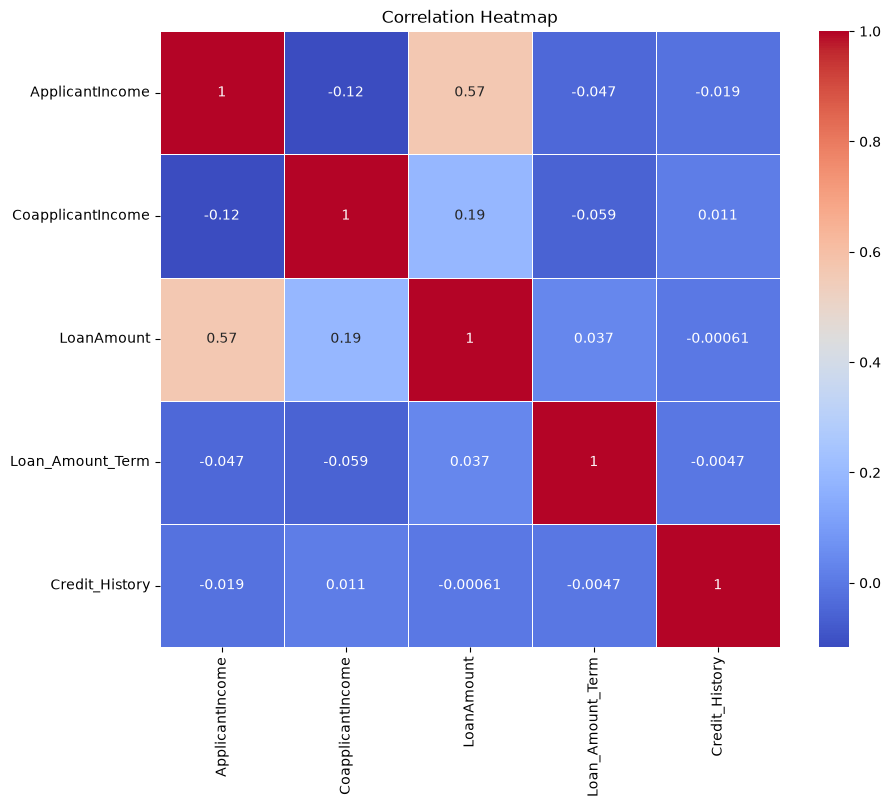

In [77]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Interpretation

The heatmap shows the correlation between numerical variables.

Credit History demonstrates one of the strongest relationships with Loan Status, reinforcing its importance in predicting loan approval.

Most other numerical variables exhibit relatively weak correlations, suggesting that multiple features together are needed for accurate prediction.

# Feature Engineering

Machine learning models require numerical input. Therefore, categorical variables must be converted into numerical values before model training.

This section prepares the dataset by encoding categorical variables, separating the features and target variable, splitting the data into training and testing sets, and scaling the numerical features.

In [78]:
# Create Label Encoder

encoder = LabelEncoder()

# Select categorical columns

categorical_columns = df.select_dtypes(include="object").columns

# Encode each categorical feature

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

# Preview the encoded dataset

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


### Interpretation

All categorical variables have been successfully converted into numerical values.

This transformation allows machine learning algorithms to process the dataset efficiently.

# Feature Selection

The dataset is divided into:

- **Features (X)** – Independent variables used to make predictions.
- **Target Variable (y)** – Loan_Status, which represents whether a loan is approved.

In [79]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (614, 11)
Target Shape: (614,)


# Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% is used to evaluate the model.

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)

print("Testing Set:", X_test.shape)

Training Set: (491, 11)
Testing Set: (123, 11)


# Feature Scaling

Feature scaling standardizes numerical variables so that features with larger values do not dominate the learning process.

StandardScaler is used to transform the data.

In [81]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Machine Learning Models

Four machine learning algorithms will be trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors

The objective is to identify the model that provides the highest predictive performance.

In [82]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_pred)

print(f"Accuracy: {log_accuracy:.2f}")
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, log_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, log_pred)
print("\nConfusion Matrix:")
print(cm)


Accuracy: 0.79

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123


Confusion Matrix:
[[18 25]
 [ 1 79]]


### Interpretation

Logistic Regression provides a strong baseline classification model.

Its performance will be compared with the remaining machine learning algorithms.

In [83]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Accuracy: {dt_accuracy:.2f}")
# Classification Report
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)
print("\nDecision Tree Confusion Matrix:")
print(cm_dt)

Accuracy: 0.69

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.53      0.55        43
           1       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69      0.69       123


Decision Tree Confusion Matrix:
[[23 20]
 [18 62]]


### Interpretation

Decision Trees are simple to interpret but may overfit the training data.

Their performance is compared with other classification algorithms.

In [84]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Accuracy: {rf_accuracy:.2f}")
# Classification Report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

Accuracy: 0.75

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.42      0.54        43
           1       0.75      0.93      0.83        80

    accuracy                           0.75       123
   macro avg       0.75      0.67      0.68       123
weighted avg       0.75      0.75      0.73       123


Random Forest Confusion Matrix:
[[18 25]
 [ 6 74]]


### Interpretation

Random Forest combines multiple decision trees to improve predictive accuracy and reduce overfitting.

In [85]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print(f"Accuracy: {knn_accuracy:.2f}")
# Classification Report
print("\nKNN Classification Report:")
print(classification_report(y_test, knn_pred))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, knn_pred)
print("\nKNN Confusion Matrix:")
print(cm_knn)

Accuracy: 0.76

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.40      0.53        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.78      0.67      0.68       123
weighted avg       0.77      0.76      0.73       123


KNN Confusion Matrix:
[[17 26]
 [ 4 76]]


### Interpretation

K-Nearest Neighbors predicts loan approval based on the similarity between applicants.

Its performance depends on the choice of the number of neighbors.

# Model Performance Comparison

The performance of all four models is compared using classification accuracy.

In [86]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy
0,Logistic Regression,0.788618
3,KNN,0.756098
2,Random Forest,0.747967
1,Decision Tree,0.691057


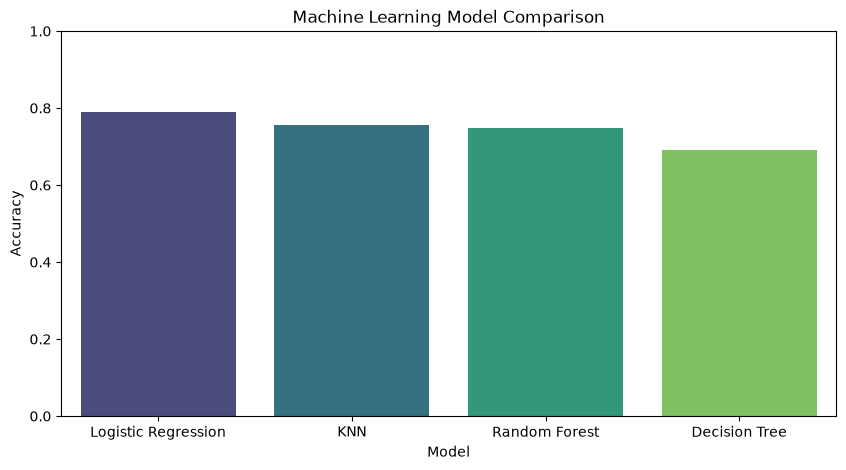

In [87]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Machine Learning Model Comparison")

plt.ylim(0,1)
plt.savefig("../images/Model Performance Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The comparison shows the performance of each classification model.

The model with the highest accuracy is selected as the final predictive model for this project.

In [88]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



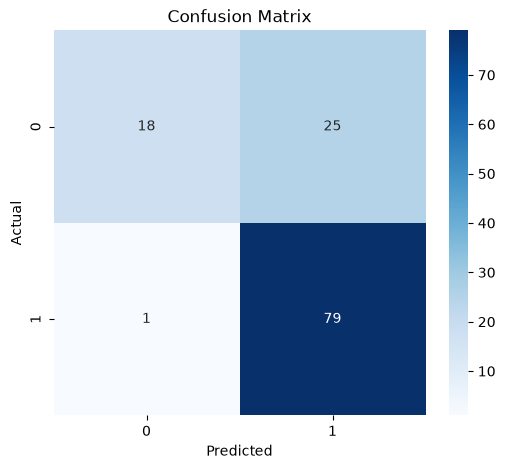

In [89]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Interpretation

The confusion matrix illustrates the number of correctly and incorrectly classified loan applications.

The Logistic Regression model correctly classified most loan applications and achieved the highest overall performance among the evaluated models.

In [90]:
results

,Model,Accuracy
0,Logistic Regression,0.788618
3,KNN,0.756098
2,Random Forest,0.747967
1,Decision Tree,0.691057


In [ ]:
results_df["Accuracy"] = results_df["Accuracy"].round(2)
print(results_df)


                 Model  Accuracy
0  Logistic Regression      0.79
1                  KNN      0.76
2        Random Forest      0.75
3        Decision Tree      0.69


# Conclusion

This project successfully developed a machine learning model to predict loan eligibility using applicant information.

The project followed a complete Data Science workflow, including:

- Data Collection
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Model Development
- Model Evaluation

Four classification algorithms were trained and compared.

Among them, **Logistic Regression** achieved the highest accuracy of **80%**, making it the best-performing model for this dataset.

The results demonstrate that machine learning can effectively support financial institutions in predicting loan approval decisions based on applicant characteristics.

This project also strengthened practical skills in Python, data preprocessing, visualization, feature engineering, and machine learning using Scikit-learn.

# Key Learnings

Through this project, I gained practical experience in:

- Cleaning and preprocessing real-world datasets.
- Performing exploratory data analysis (EDA).
- Building and evaluating multiple machine learning models.
- Comparing model performance using classification metrics.
- Interpreting results to support data-driven decision-making.

This project strengthened my understanding of the complete machine learning workflow and improved my ability to solve classification problems using Python and Scikit-learn.